In [59]:
import os
import uuid
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain.prompts import PromptTemplate
from IPython.display import Image, display

In [61]:
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, verbose=True)

In [62]:
def add(agent_state):
    prompt = PromptTemplate.from_template(
        template="""Return the sum of {num1} and {num2}"""
    )
    chain = prompt | llm
    response = chain.invoke(
        {"num1": agent_state["num1"], "num2": agent_state["num2"]}
    ).content
    return {"addition": str(response)}

In [126]:
def review(agent_state):
    approval = interrupt(

        {

            "question": "Do you approve the addition result?",

            "addition": agent_state["addition"],

        }

    )
    if approval == "yes":
        return Command(goto="finalize")
    else:
        return Command(goto="add")

    # if approval == "yes":
    #     return {"next": "finalize"}
    # else:
    #     return {"next": "add"}

In [127]:
def finalize(agent_state):
    response = "Success !!!"
    return {"final_result": response}

In [128]:
def orchestrate():
    class AgentState(TypedDict):
        num1: int
        num2: int
        addition: str
        final_result: str
        pass

    graph = StateGraph(AgentState)

    graph.add_node("add", add)
    graph.add_node("reviewal", review)
    graph.add_node("finalize", finalize)

    graph.set_entry_point("add")
    graph.add_edge("add", "reviewal")
    graph.add_conditional_edges(
        "reviewal",
        lambda x: x["next"],
        {
            "finalize": "finalize",
            "add": "add"
        }
    )
    graph.set_finish_point("finalize")

    checkpointer = InMemorySaver()

    return graph.compile(checkpointer=checkpointer)

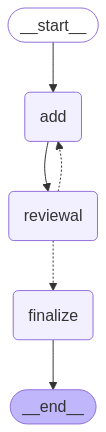

In [129]:
app = orchestrate()
display(Image(app.get_graph().draw_mermaid_png()))

In [92]:
u_id = str(uuid.uuid4())
thread_config = {"configurable": {"thread_id": u_id}}
result = app.invoke(input={"num1": 1, "num2": 4}, config=thread_config)

print(result)

{'num1': 1, 'num2': 4, 'addition': 'The sum of 1 and 4 is 5.'}


In [93]:
state = app.get_state(thread_config)
state

StateSnapshot(values={'num1': 1, 'num2': 4, 'addition': 'The sum of 1 and 4 is 5.'}, next=('reviewal',), config={'configurable': {'thread_id': '85d8c8b3-ecd7-4f14-9829-79f5f5f8bfc8', 'checkpoint_ns': '', 'checkpoint_id': '1f007daa-7bed-6d19-8001-8fcb34b05643'}}, metadata={'source': 'loop', 'writes': {'add': {'addition': 'The sum of 1 and 4 is 5.'}}, 'thread_id': '85d8c8b3-ecd7-4f14-9829-79f5f5f8bfc8', 'step': 1, 'parents': {}}, created_at='2025-03-23T11:33:34.705384+00:00', parent_config={'configurable': {'thread_id': '85d8c8b3-ecd7-4f14-9829-79f5f5f8bfc8', 'checkpoint_ns': '', 'checkpoint_id': '1f007daa-733d-623c-8000-44c7d1a065fb'}}, tasks=(PregelTask(id='ef31c2fd-79fe-2d62-8fc6-16925480ceb4', name='reviewal', path=('__pregel_pull', 'reviewal'), error=None, interrupts=(Interrupt(value={'question': 'Do you approve the addition result?', 'addition': 'The sum of 1 and 4 is 5.'}, resumable=True, ns=['reviewal:ef31c2fd-79fe-2d62-8fc6-16925480ceb4'], when='during'),), state=None, result=No

In [94]:
state.tasks

(PregelTask(id='ef31c2fd-79fe-2d62-8fc6-16925480ceb4', name='reviewal', path=('__pregel_pull', 'reviewal'), error=None, interrupts=(Interrupt(value={'question': 'Do you approve the addition result?', 'addition': 'The sum of 1 and 4 is 5.'}, resumable=True, ns=['reviewal:ef31c2fd-79fe-2d62-8fc6-16925480ceb4'], when='during'),), state=None, result=None),)

In [95]:
state.tasks[0].interrupts

(Interrupt(value={'question': 'Do you approve the addition result?', 'addition': 'The sum of 1 and 4 is 5.'}, resumable=True, ns=['reviewal:ef31c2fd-79fe-2d62-8fc6-16925480ceb4'], when='during'),)

In [96]:
# Resume graph
response = app.invoke(
    Command(resume="no"),
    config=thread_config
)
print(thread_config)
response

{'configurable': {'thread_id': '85d8c8b3-ecd7-4f14-9829-79f5f5f8bfc8'}}


{'num1': 1, 'num2': 4, 'addition': 'The sum of 1 and 4 is 5.'}

In [97]:
resp = app.invoke(
    Command(resume="yes"),
    config={"configurable": {"thread_id": "85d8c8b3-ecd7-4f14-9829-79f5f5f8bfc8"}}
)
resp

{'num1': 1,
 'num2': 4,
 'addition': 'The sum of 1 and 4 is 5.',
 'final_result': 'Success !!!'}

In [124]:
print(app.get_state(config={"configurable": {"thread_id": "111"}}))

StateSnapshot(values={'num1': 10, 'num2': 40, 'addition': 'The sum of 10 and 40 is 50.'}, next=('reviewal',), config={'configurable': {'thread_id': '111', 'checkpoint_ns': '', 'checkpoint_id': '1f007e35-52ee-6a30-8001-701b5d4ea16b'}}, metadata={'source': 'loop', 'writes': {'add': {'addition': 'The sum of 10 and 40 is 50.'}}, 'thread_id': '111', 'step': 1, 'parents': {}}, created_at='2025-03-23T12:35:41.659396+00:00', parent_config={'configurable': {'thread_id': '111', 'checkpoint_ns': '', 'checkpoint_id': '1f007e35-49df-61f1-8000-3a8ee79f5e0d'}}, tasks=(PregelTask(id='5c96f3e0-6440-3c69-6d2c-c779c1201adb', name='reviewal', path=('__pregel_pull', 'reviewal'), error=None, interrupts=(Interrupt(value={'question': 'Do you approve the addition result?', 'addition': 'The sum of 10 and 40 is 50.'}, resumable=True, ns=['reviewal:5c96f3e0-6440-3c69-6d2c-c779c1201adb'], when='during'),), state=None, result=None),))


In [123]:
# Input
initial_input = {"num1": 10, "num2": 40}

# Thread
thread = {"configurable": {"thread_id": "111"}}

# Run the graph until the first interruption
for event in app.stream(initial_input, thread, stream_mode="values"):
    print(event)
    print("\n")

{'num1': 10, 'num2': 40}


{'num1': 10, 'num2': 40, 'addition': 'The sum of 10 and 40 is 50.'}


